## Logistic regression, smoking data

In [28]:
# usual imports in a classic ML pipeline for Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# for accuracy: isolation forest
from sklearn import feature_selection
from sklearn.ensemble import IsolationForest

In [29]:
# load the data
df = pd.read_csv("../Datasets/smoking.csv")

# let's quickly see the first 10 rows of data
df.head(10)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0
5,5,M,30,180,75,85.0,1.2,1.2,1.0,1.0,...,16.2,1.0,1.2,18.0,27.0,33.0,Y,0,Y,0
6,6,M,40,160,60,85.5,1.0,1.0,1.0,1.0,...,17.0,1.0,0.7,21.0,27.0,39.0,Y,1,Y,1
7,7,M,45,165,90,96.0,1.2,1.0,1.0,1.0,...,15.0,1.0,1.3,38.0,71.0,111.0,Y,0,Y,0
8,9,F,50,150,60,85.0,0.7,0.8,1.0,1.0,...,13.7,1.0,0.8,31.0,31.0,14.0,Y,0,N,0
9,10,M,45,175,75,89.0,1.0,1.0,1.0,1.0,...,16.0,1.0,0.8,26.0,24.0,63.0,Y,0,N,0


Dataset originates from
https://www.kaggle.com/datasets/kukuroo3/body-signal-of-smoking.

This dataset is a collection of basic health biological signal data.
The goal is to determine the presence or absence of smoking through bio-signals.

Columns include:

- ID : index
- gender
- age : 5-years gap
- height(cm)
- weight(kg)
- waist(cm) : Waist circumference length
- eyesight(left)
- eyesight(right)
- hearing(left)
- hearing(right)
- systolic : Blood pressure
- relaxation : Blood pressure
- fasting blood sugar
- Cholesterol : total
- triglyceride
- HDL : cholesterol type
- LDL : cholesterol type
- hemoglobin
- Urine protein
- serum creatinine
- AST : glutamic oxaloacetic transaminase type
- ALT : glutamic oxaloacetic transaminase type
- Gtp : γ-GTP
- oral : Oral Examination status
- dental caries
- tartar : tartar status (hammaskivi, ei pihvi)
- smoking

In [30]:
# let's also unify the spelling of column names

# ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),
# hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,
# hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking

headers = list(df.columns.values)
new_headers = []

for i in headers:
    clean_text = i.strip()

    if clean_text.isupper():
        new_headers.append(clean_text)

    else:
        new_headers.append(clean_text.title())    

df.columns = new_headers

# Handle exceptions
df.rename(columns={"Gtp": "GTP"}, inplace=True)
df.rename(columns={"Height(Cm)": "Height(cm)"}, inplace=True)
df.rename(columns={"Weight(Kg)": "Weight(kg)"}, inplace=True)
df.rename(columns={"Waist(Cm)": "Waist(cm)"}, inplace=True)   
print(df.columns)

Index(['ID', 'Gender', 'Age', 'Height(cm)', 'Weight(kg)', 'Waist(cm)',
       'Eyesight(Left)', 'Eyesight(Right)', 'Hearing(Left)', 'Hearing(Right)',
       'Systolic', 'Relaxation', 'Fasting Blood Sugar', 'Cholesterol',
       'Triglyceride', 'HDL', 'LDL', 'Hemoglobin', 'Urine Protein',
       'Serum Creatinine', 'AST', 'ALT', 'GTP', 'Oral', 'Dental Caries',
       'Tartar', 'Smoking'],
      dtype='object')


In [31]:
# check duplicates 
df.duplicated().sum()

np.int64(0)

In [32]:
# everyone has a mouth? I'm deeming this: useless
df['Oral'].value_counts()

Oral
Y    55692
Name: count, dtype: int64

Smoking                1.000000
Hemoglobin             0.400678
Height(cm)             0.396675
Weight(kg)             0.302780
Triglyceride           0.251799
GTP                    0.236619
Waist(cm)              0.226259
Serum Creatinine       0.216812
HDL                    0.178470
Age                    0.162557
Relaxation             0.108309
Dental Caries          0.103857
Fasting Blood Sugar    0.100279
ALT                    0.097338
Systolic               0.073109
Eyesight(Right)        0.063017
Eyesight(Left)         0.061204
AST                    0.059253
LDL                    0.045220
Cholesterol            0.028548
Hearing(Left)          0.023209
Hearing(Right)         0.018855
Urine Protein          0.014267
ID                     0.011476
Name: Abs_SMOKING, dtype: float64

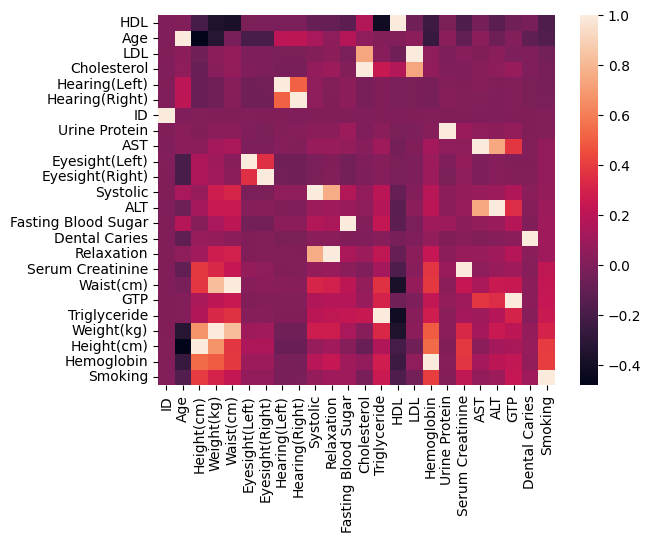

In [33]:
# There are some columns that I see are probably hurting the overall accuracy of the model.
# I want to see what the correlations look like at the moment.

correlation = df.corr(numeric_only=True).sort_values(by="Smoking")

sns.heatmap(correlation)

correlation["Abs_SMOKING"] = abs(correlation["Smoking"])

# Sort by the new absolute column in descending order
correlation = correlation.sort_values(by="Abs_SMOKING", ascending=False)

# Display the result
correlation["Abs_SMOKING"]

In [34]:
# user ID is an identifier, drop it
# oral is all yes, and none of nos, dropping it too 
df = df.drop("ID", axis=1)          # Insignificant
df = df.drop("Oral", axis=1)        # Everyone has a mouth

# I experimented with dropping these columns. 
# It didn't have any effect on the accuracy score.

# df = df.drop("Urine Protein", axis=1)
# df = df.drop("Hearing(Right)", axis=1)
# df = df.drop("Hearing(Left)", axis=1)
# df = df.drop("Cholesterol", axis=1)
# df = df.drop("LDL", axis=1)
# df = df.drop("AST", axis=1)
df

,Gender,Age,Height(cm),Weight(kg),Waist(cm),Eyesight(Left),Eyesight(Right),Hearing(Left),Hearing(Right),Systolic,...,LDL,Hemoglobin,Urine Protein,Serum Creatinine,AST,ALT,GTP,Dental Caries,Tartar,Smoking
0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,126.0,12.9,1.0,0.7,18.0,19.0,27.0,0,Y,0
1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,127.0,12.7,1.0,0.6,22.0,19.0,18.0,0,Y,0
2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,151.0,15.8,1.0,1.0,21.0,16.0,22.0,0,N,1
3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,226.0,14.7,1.0,1.0,19.0,26.0,18.0,0,Y,0
4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,107.0,12.5,1.0,0.6,16.0,14.0,22.0,0,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55687,F,40,170,65,75.0,0.9,0.9,1.0,1.0,110.0,...,118.0,12.3,1.0,0.6,14.0,7.0,10.0,1,Y,0
55688,F,45,160,50,70.0,1.2,1.2,1.0,1.0,101.0,...,79.0,14.0,1.0,0.9,20.0,12.0,14.0,0,Y,0
55689,F,55,160,50,68.5,1.0,1.2,1.0,1.0,117.0,...,63.0,12.4,1.0,0.5,17.0,11.0,12.0,0,N,0
55690,M,60,165,60,78.0,0.8,1.0,1.0,1.0,133.0,...,146.0,14.4,1.0,0.7,20.0,19.0,18.0,0,N,0


In [35]:
df['Gender'].value_counts()

Gender
M    35401
F    20291
Name: count, dtype: int64

In [36]:
df.head(5)

,Gender,Age,Height(cm),Weight(kg),Waist(cm),Eyesight(Left),Eyesight(Right),Hearing(Left),Hearing(Right),Systolic,...,LDL,Hemoglobin,Urine Protein,Serum Creatinine,AST,ALT,GTP,Dental Caries,Tartar,Smoking
0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,126.0,12.9,1.0,0.7,18.0,19.0,27.0,0,Y,0
1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,127.0,12.7,1.0,0.6,22.0,19.0,18.0,0,Y,0
2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,151.0,15.8,1.0,1.0,21.0,16.0,22.0,0,N,1
3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,226.0,14.7,1.0,1.0,19.0,26.0,18.0,0,Y,0
4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,107.0,12.5,1.0,0.6,16.0,14.0,22.0,0,N,0


### STEP 2: Handle missing/duplicate values and HANDLE ALL CATEGORICAL VARIABLES CORRECTLY
We only have one binary variable, so we don't need to process other types of categoricals.

In [37]:
# this just converts the value of binary column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ['Gender', 'Tartar']
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

**There's no ordinal or nominal categories here, we can proceed to X/y -phase**

In [38]:
df.head()

,Gender,Age,Height(cm),Weight(kg),Waist(cm),Eyesight(Left),Eyesight(Right),Hearing(Left),Hearing(Right),Systolic,...,LDL,Hemoglobin,Urine Protein,Serum Creatinine,AST,ALT,GTP,Dental Caries,Tartar,Smoking
0,0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,126.0,12.9,1.0,0.7,18.0,19.0,27.0,0,1,0
1,0,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,127.0,12.7,1.0,0.6,22.0,19.0,18.0,0,1,0
2,1,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,151.0,15.8,1.0,1.0,21.0,16.0,22.0,0,0,1
3,1,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,226.0,14.7,1.0,1.0,19.0,26.0,18.0,0,1,0
4,0,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,107.0,12.5,1.0,0.6,16.0,14.0,22.0,0,0,0


### X/y and train/test -splits

In [39]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Smoking", axis=1)

# our target variable is y
y = df['Smoking']

In [40]:
# For accuracy I was suggested to use IsolationForest

# we make an IsolationForest variables
# contamination='auto' lets the model decide the threshold
IsolationForest = IsolationForest(random_state=43, contamination='auto')

# Now we take the dataframe X (so the dataframe without smoking column).
# fit_predict makes a mask. It returns -1 for outliers and 1 for inliers. 
# We take the rows that have 1 as the retun value (so they are inliers) 
# and store the mask as a variable called IsolationForest_normal
IsolationForest_normal = IsolationForest.fit_predict(X)==1

IsolationForest_normal


array([ True,  True,  True, ...,  True,  True,  True], shape=(55692,))

In [41]:
# We use the IsolationForest_normal to make 

X_clean = X[IsolationForest_normal]
y_clean = y[IsolationForest_normal]

In [42]:
X

,Gender,Age,Height(cm),Weight(kg),Waist(cm),Eyesight(Left),Eyesight(Right),Hearing(Left),Hearing(Right),Systolic,...,HDL,LDL,Hemoglobin,Urine Protein,Serum Creatinine,AST,ALT,GTP,Dental Caries,Tartar
0,0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,73.0,126.0,12.9,1.0,0.7,18.0,19.0,27.0,0,1
1,0,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,42.0,127.0,12.7,1.0,0.6,22.0,19.0,18.0,0,1
2,1,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,55.0,151.0,15.8,1.0,1.0,21.0,16.0,22.0,0,0
3,1,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,45.0,226.0,14.7,1.0,1.0,19.0,26.0,18.0,0,1
4,0,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,62.0,107.0,12.5,1.0,0.6,16.0,14.0,22.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55687,0,40,170,65,75.0,0.9,0.9,1.0,1.0,110.0,...,75.0,118.0,12.3,1.0,0.6,14.0,7.0,10.0,1,1
55688,0,45,160,50,70.0,1.2,1.2,1.0,1.0,101.0,...,73.0,79.0,14.0,1.0,0.9,20.0,12.0,14.0,0,1
55689,0,55,160,50,68.5,1.0,1.2,1.0,1.0,117.0,...,79.0,63.0,12.4,1.0,0.5,17.0,11.0,12.0,0,0
55690,1,60,165,60,78.0,0.8,1.0,1.0,1.0,133.0,...,48.0,146.0,14.4,1.0,0.7,20.0,19.0,18.0,0,0


In [ ]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.3, )

### NOTE! one difference when compared to previous exercise, WE NEED TO SCALE OUR SUPPORT VARIABLES FOR logistic regression!

In [44]:
# initialize the scaler and process X-values
# IN MOST CASES you can experiment with StandardScaler or MinMaxWScaler
# BUT ONLY USE ONE SCALER AT A TIME FOR SUPPORT VARIABLES
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# FIT the scaler only to X-training data
# and only transform the test data with that
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [45]:
# you can inspect how the original values have now 
# switched to the scaled ones
X_train

array([[-1.31825622,  0.9509835 , -0.51773417, ..., -0.25967528,
        -0.5120755 , -1.12811753],
       [ 0.75857787,  0.52513703,  0.03147582, ...,  2.49533883,
        -0.5120755 ,  0.88643247],
       [ 0.75857787, -1.17824883,  0.58068581, ..., -0.1022459 ,
        -0.5120755 ,  0.88643247],
       ...,
       [ 0.75857787, -0.3265559 ,  1.12989579, ...,  0.21261285,
        -0.5120755 ,  0.88643247],
       [ 0.75857787, -1.60409529,  2.22831577, ...,  0.47499515,
         1.95283705,  0.88643247],
       [ 0.75857787, -0.3265559 ,  1.12989579, ..., -0.3646282 ,
        -0.5120755 , -1.12811753]], shape=(37026, 24))

### Train the logistic regression model

In [46]:
# create the model and train it with the data
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Classification error metrics

In [47]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

In [48]:
# print the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79     10075
           1       0.64      0.68      0.66      5794

    accuracy                           0.74     15869
   macro avg       0.73      0.73      0.73     15869
weighted avg       0.75      0.74      0.75     15869


Model overall accuracy: 74.43%


<Axes: >

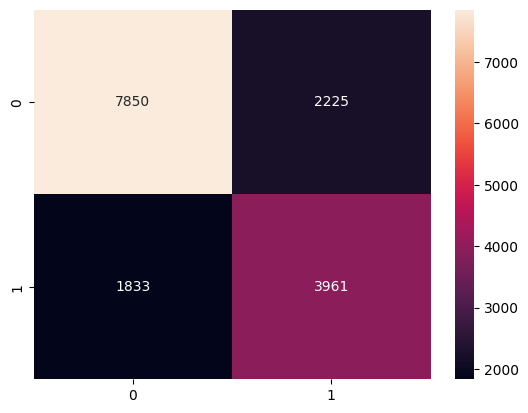

In [49]:
# see the confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')

In [50]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means you could get the same result with just random guessing
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

0.8313181343582092

### Using the model in practice

In [51]:
df.columns

Index(['Gender', 'Age', 'Height(cm)', 'Weight(kg)', 'Waist(cm)',
       'Eyesight(Left)', 'Eyesight(Right)', 'Hearing(Left)', 'Hearing(Right)',
       'Systolic', 'Relaxation', 'Fasting Blood Sugar', 'Cholesterol',
       'Triglyceride', 'HDL', 'LDL', 'Hemoglobin', 'Urine Protein',
       'Serum Creatinine', 'AST', 'ALT', 'GTP', 'Dental Caries', 'Tartar',
       'Smoking'],
      dtype='object')

In [52]:
# usually in GUI application we save the model-object / variable into a file (by using joblib-module)
# and in the GUI application => we load the saved model from the file
# and use the model just like here below


# map all the variables from the user
# into a Python dictionary
# the variable names have to match with the original dataset
tester_row = {
    'Gender': 0,
    'Age': 30,
    'Height(cm)': 180,
    'Weight(kg)': 80,
    'Waist(cm)': 91,
    'Eyesight(Left)': 0.5,
    'Eyesight(Right)': 0.5,
    'Hearing(Left)': 1.0,
    'Hearing(Right)': 1.0,
    'Systolic': 138,
    'Relaxation': 82,
    'Fasting Blood Sugar': 130,
    'Cholesterol': 322,
    'Triglyceride': 254,
    'HDL': 73,
    'LDL': 226,
    'Hemoglobin': 14.7,
    'Urine Protein': 1.0,
    'Serum Creatinine': 0.8,
    'AST': 26,
    'ALT': 22,
    'GTP': 63,
    'Dental Caries': 1,
    'Tartar': 1
}

# convert to pandas format
tester_row = pd.DataFrame([tester_row])

# SINCE WE SCALED our support variables earlier
# WE HAVE TO DO IT HERE AS WELL
tester_row = sc.transform(tester_row)


In [53]:
print("All probabilities by category:")
print(model.predict_proba(tester_row))
print()

# change these based on your original data
labels = ["No", "Yes"]

print("Is this a smoker (Yes/No):")
result = labels[model.predict(tester_row)[0]]
print(result)
print("-------------------")

All probabilities by category:
[[0.82611418 0.17388582]]

Is this a smoker (Yes/No):
No
-------------------


Smoking                1.000000
Gender                 0.510340
Hemoglobin             0.400678
Height(cm)             0.396675
Weight(kg)             0.302780
Triglyceride           0.251799
GTP                    0.236619
Waist(cm)              0.226259
Serum Creatinine       0.216812
HDL                    0.178470
Age                    0.162557
Relaxation             0.108309
Dental Caries          0.103857
Fasting Blood Sugar    0.100279
Tartar                 0.098655
ALT                    0.097338
Systolic               0.073109
Eyesight(Right)        0.063017
Eyesight(Left)         0.061204
AST                    0.059253
LDL                    0.045220
Cholesterol            0.028548
Hearing(Left)          0.023209
Hearing(Right)         0.018855
Urine Protein          0.014267
Name: Abs_SMOKING, dtype: float64

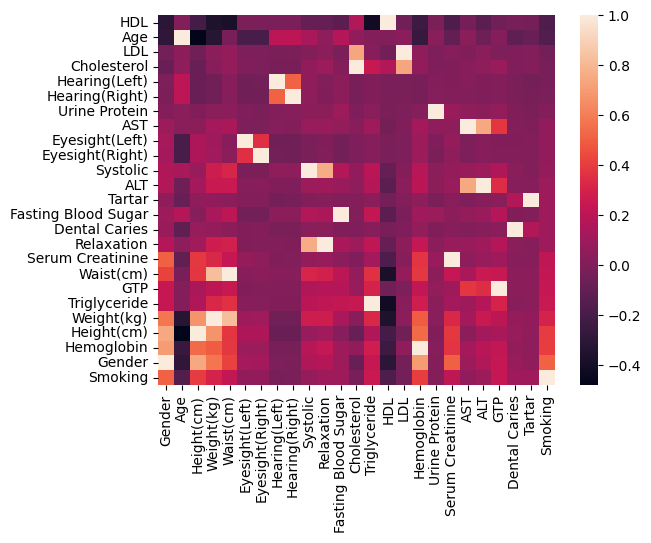

In [54]:
correlation = df.corr(numeric_only=True).sort_values(by="Smoking")

sns.heatmap(correlation)

correlation["Abs_SMOKING"] = abs(correlation["Smoking"])
correlation["Abs_SMOKING"]

# Sort by the new absolute column in descending order
correlation = correlation.sort_values(by="Abs_SMOKING", ascending=False)
correlation["Abs_SMOKING"]

The result doesn't please me greatly with or without the isolation forest. Maybe I used it in a wrong manner, but the isolation forest didn't effect the accuracy at all. I also tried "raakalla kädellä" by dropping columns that show poor correlation with the target. Still the accuracy remains around 74 %. ROC-AUC is decent at 82. That didn't move much either.

The origin of the dataset is kind of nebulous. The country/countries and the time of the data collection are unknowns. Confounded by some of the correlations, I went to Gemini. It suggested that perhaps the correlation between Gender and Smoking could be on the stronger side because of asia. Here is a study I found about the subject: https://www.researchgate.net/publication/23150862_Gender_Differences_in_Smoking_Behaviors_in_an_Asian_Population. In the abstarct it says: "The male/female smoking rate ratio was 9.5 (45.7% vs. 4.8%). Men smoked significantly more cigarettes per day than women (18 vs. 11)."